# Exploratory Data Analysis

Loading MovieLens 100K and performing EDA with 6+ visualizations.

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append('..')
from src.utils.data_loader import load_movielens
from src.utils.preprocessor import clean_movies, clean_ratings

os.makedirs('../reports/figures', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

## 1. Load Data

In [2]:
ratings_df, movies_df = load_movielens(
    ratings_path='../data/raw/u.data',
    movies_path='../data/raw/u.item'
)

print('Ratings shape:', ratings_df.shape)
print('Movies shape:', movies_df.shape)
print('\nRatings sample:')
display(ratings_df.head())
print('\nMovies sample:')
display(movies_df.head())

Ratings shape: (100000, 4)
Movies shape: (1682, 22)

Ratings sample:


,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596



Movies sample:


,item_id,title,release_date,unknown,Action,Adventure,Animation,Childrens,Comedy,Crime,...,Fantasy,Film_Noir,Horror,Musical,Mystery,Romance,Sci_Fi,Thriller,War,Western
0,1,Toy Story (1995),01-Jan-1995,0,0,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0


## 2. Missing Values

In [3]:
print('Missing values in ratings_df:')
print(ratings_df.isnull().sum())
print('\nMissing values in movies_df:')
print(movies_df.isnull().sum())

ratings_df = clean_ratings(ratings_df)
movies_df  = clean_movies(movies_df)
print('\nCleaning done!')

Missing values in ratings_df:
user_id      0
item_id      0
rating       0
timestamp    0
dtype: int64

Missing values in movies_df:
item_id         0
title           0
release_date    1
unknown         0
Action          0
Adventure       0
Animation       0
Childrens       0
Comedy          0
Crime           0
Documentary     0
Drama           0
Fantasy         0
Film_Noir       0
Horror          0
Musical         0
Mystery         0
Romance         0
Sci_Fi          0
Thriller        0
War             0
Western         0
dtype: int64

Cleaning done!


## 3. Chart 1 — Rating Distribution

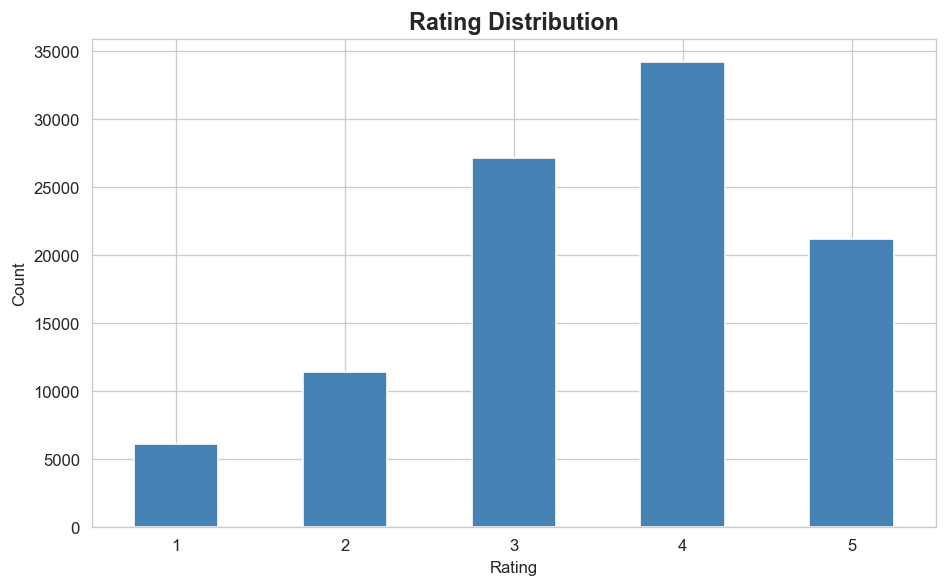

Saved: rating_distribution.png


In [4]:
plt.figure(figsize=(8, 5))
ratings_df['rating'].value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Rating Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../reports/figures/rating_distribution.png', dpi=150)
plt.show()
print('Saved: rating_distribution.png')

## 4. Chart 2 — Ratings per User

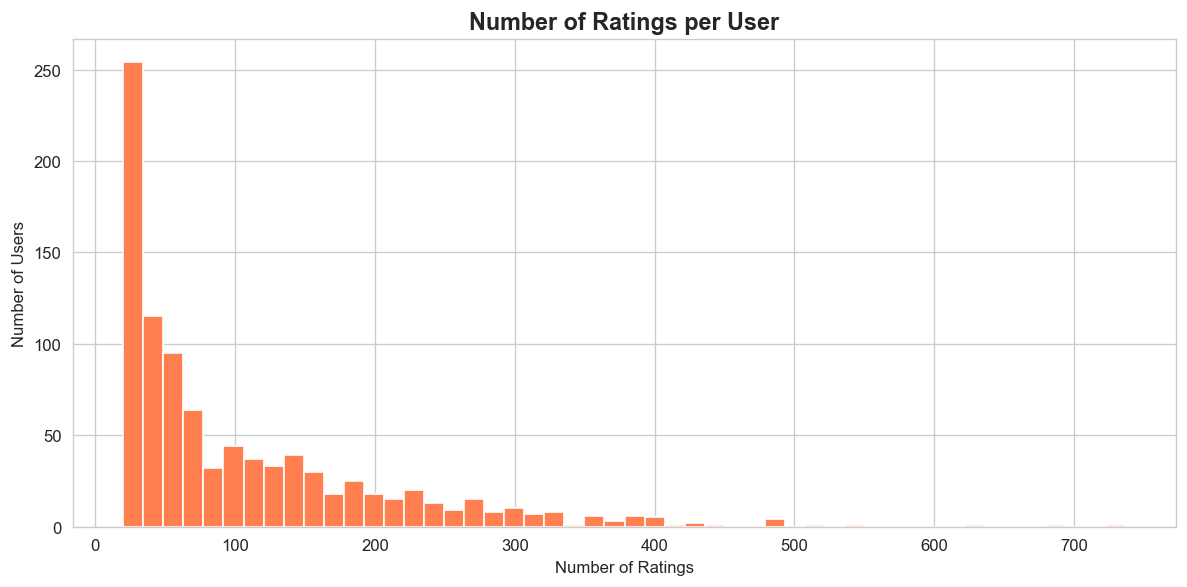

Saved: ratings_per_user.png


In [5]:
ratings_per_user = ratings_df.groupby('user_id').size()

plt.figure(figsize=(10, 5))
plt.hist(ratings_per_user, bins=50, color='coral', edgecolor='white')
plt.title('Number of Ratings per User', fontsize=14, fontweight='bold')
plt.xlabel('Number of Ratings')
plt.ylabel('Number of Users')
plt.tight_layout()
plt.savefig('../reports/figures/ratings_per_user.png', dpi=150)
plt.show()
print('Saved: ratings_per_user.png')

## 5. Chart 3 — Ratings per Movie

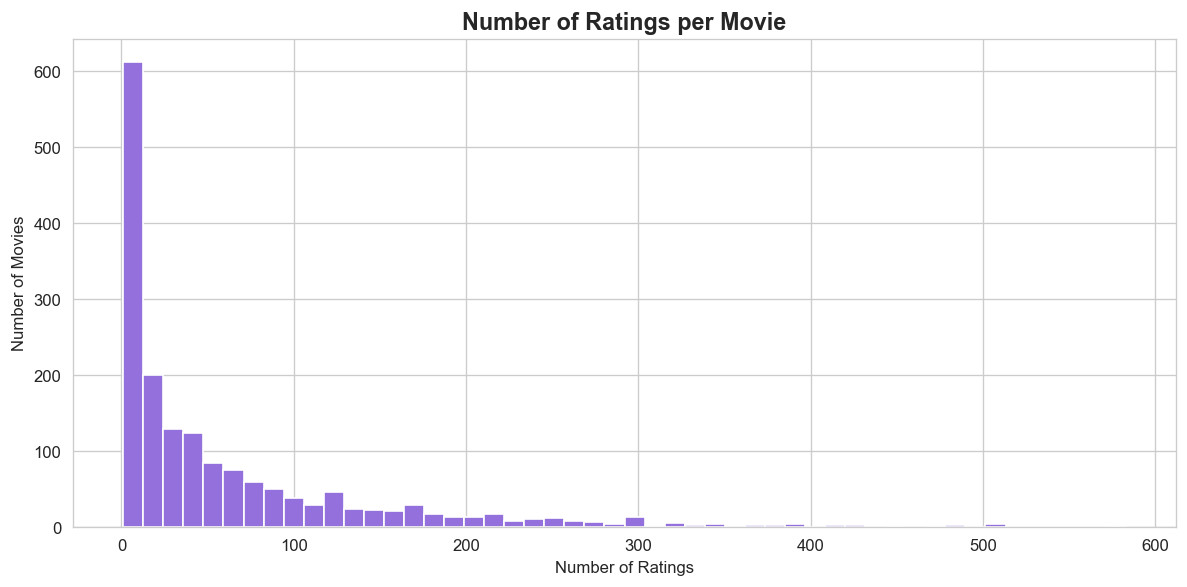

Saved: ratings_per_movie.png


In [6]:
ratings_per_movie = ratings_df.groupby('item_id').size()

plt.figure(figsize=(10, 5))
plt.hist(ratings_per_movie, bins=50, color='mediumpurple', edgecolor='white')
plt.title('Number of Ratings per Movie', fontsize=14, fontweight='bold')
plt.xlabel('Number of Ratings')
plt.ylabel('Number of Movies')
plt.tight_layout()
plt.savefig('../reports/figures/ratings_per_movie.png', dpi=150)
plt.show()
print('Saved: ratings_per_movie.png')

## 6. Chart 4 — Top 10 Most Rated Movies

C:\Users\megha\AppData\Local\Temp\ipykernel_19580\3841291040.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, x='count', y='title', palette='Blues_r')


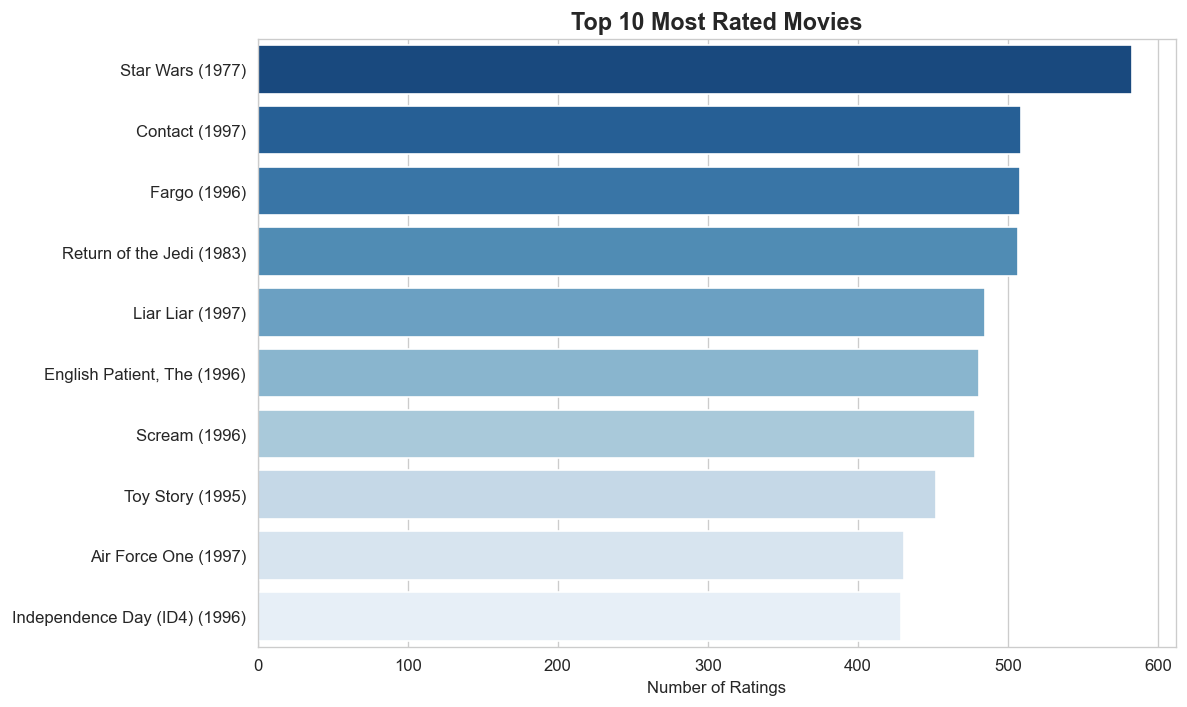

Saved: top10_movies.png


In [7]:
top10 = ratings_df.groupby('item_id').size().nlargest(10).reset_index()
top10.columns = ['item_id', 'count']
top10 = top10.merge(movies_df[['item_id', 'title']], on='item_id')

plt.figure(figsize=(10, 6))
sns.barplot(data=top10, x='count', y='title', palette='Blues_r')
plt.title('Top 10 Most Rated Movies', fontsize=14, fontweight='bold')
plt.xlabel('Number of Ratings')
plt.ylabel('')
plt.tight_layout()
plt.savefig('../reports/figures/top10_movies.png', dpi=150)
plt.show()
print('Saved: top10_movies.png')

## 7. Chart 5 — Rating Trend Over Time

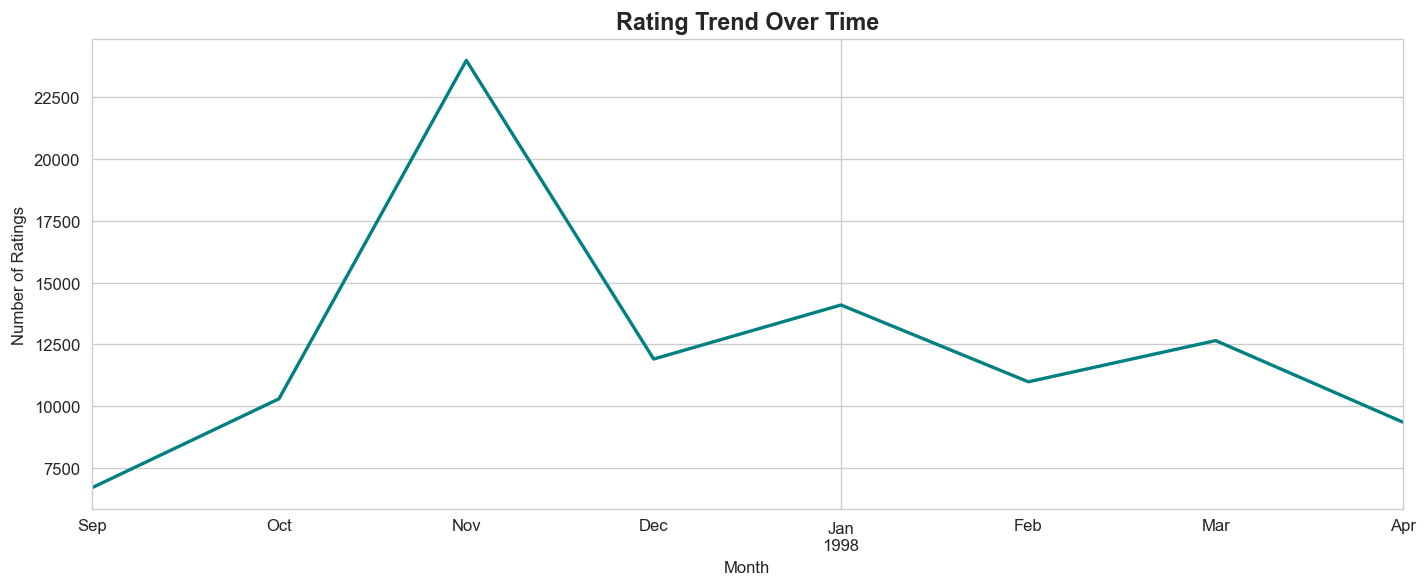

Saved: rating_trend.png


In [8]:
ratings_df['date'] = pd.to_datetime(ratings_df['timestamp'], unit='s')
ratings_df['month'] = ratings_df['date'].dt.to_period('M')
trend = ratings_df.groupby('month').size()

plt.figure(figsize=(12, 5))
trend.plot(color='teal', linewidth=2)
plt.title('Rating Trend Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Ratings')
plt.tight_layout()
plt.savefig('../reports/figures/rating_trend.png', dpi=150)
plt.show()
print('Saved: rating_trend.png')

## 8. Chart 6 — Genre Distribution

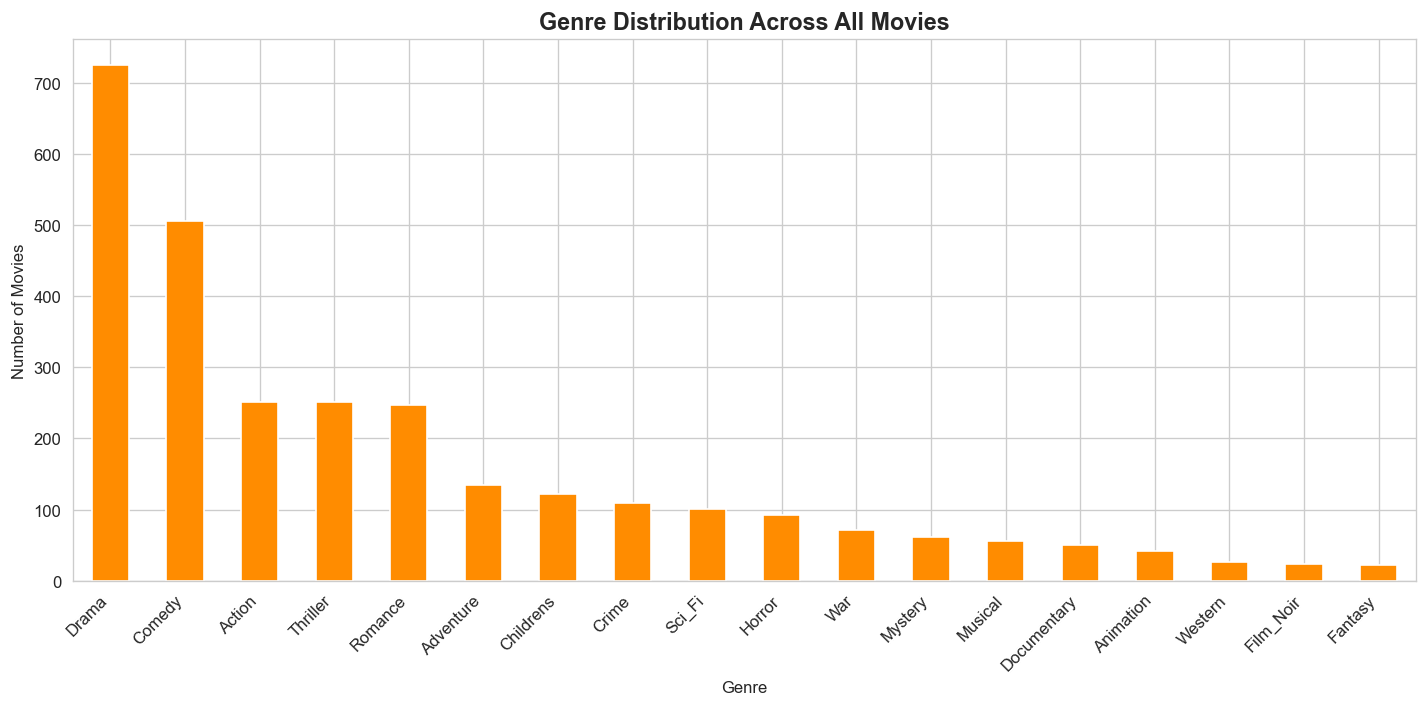

Saved: genre_distribution.png


In [9]:
genre_cols = [
    'Action', 'Adventure', 'Animation', 'Childrens', 'Comedy',
    'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film_Noir',
    'Horror', 'Musical', 'Mystery', 'Romance', 'Sci_Fi',
    'Thriller', 'War', 'Western'
]
genre_counts = movies_df[genre_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
genre_counts.plot(kind='bar', color='darkorange', edgecolor='white')
plt.title('Genre Distribution Across All Movies', fontsize=14, fontweight='bold')
plt.xlabel('Genre')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../reports/figures/genre_distribution.png', dpi=150)
plt.show()
print('Saved: genre_distribution.png')

## 9. Save Cleaned Data

In [10]:
ratings_df.to_csv('../data/processed/ratings_clean.csv', index=False)
movies_df.to_csv('../data/processed/movies_clean.csv', index=False)
print('ratings_clean.csv saved:', ratings_df.shape)
print('movies_clean.csv saved:', movies_df.shape)

ratings_clean.csv saved: (100000, 6)
movies_clean.csv saved: (1682, 22)
